# ECCB 2026 regulatory annotation tutorial - R / Bioconductor

## Overview

This notebook provides a practical workflow for exploring cis-regulatory annotations and open chromatin evidence tracks in specific genomic regions.

It:

- Downloads example regulatory annotation and open-chromatin datasets.
- Reads ENCODE candidate cis-regulatory elements (cCREs), Ensembl Regulatory Features, and Forebrain E13.5 ATAC-seq and DNase-seq peaks from Ensembl.
- Standardizes chromosome names and harmonizes the input data.
- Summarizes and compares regulatory feature types from ENCODE and Ensembl.
- Identifies regulatory features overlapping the selected query regions.
- Combines the annotation sources into a single table.
- Selects and exports promoter-like features and identifies active promoters supported by open-chromatin evidence in Forebrain E13.5.
- Produces summary tables, plots, and output files for downstream analysis.

## Installing and loading required packages


The first execution of this notebook may take 5–10 minutes, as several CRAN and Bioconductor packages (including their dependencies) need to be installed. This step only needs to be completed once per Colab session.

In [1]:
install_if_missing <- function(cran_pkgs = character(),
                               bioc_pkgs = character()) {

  ## ---- CRAN packages --------------------------------------------------------
  missing_cran <- cran_pkgs[
    !vapply(cran_pkgs, requireNamespace, logical(1), quietly = TRUE)
  ]

  if (length(missing_cran) > 0) {
    message(
      "Installing CRAN packages: ",
      paste(missing_cran, collapse = ", ")
    )

    install.packages(
      missing_cran,
      repos = "https://cloud.r-project.org"
    )
  } else {
    message("All required CRAN packages are already installed.")
  }

  ## ---- Bioconductor packages -----------------------------------------------
  missing_bioc <- bioc_pkgs[
    !vapply(bioc_pkgs, requireNamespace, logical(1), quietly = TRUE)
  ]

  if (length(missing_bioc) > 0) {

    if (!requireNamespace("BiocManager", quietly = TRUE)) {
      install.packages(
        "BiocManager",
        repos = "https://cloud.r-project.org"
      )
    }

    message(
      "Installing Bioconductor packages (this may take several minutes): ",
      paste(missing_bioc, collapse = ", ")
    )

    BiocManager::install(
      missing_bioc,
      ask = FALSE,
      update = FALSE
    )

  } else {
    message("All required Bioconductor packages are already installed.")
  }
}

install_if_missing(
  cran_pkgs = c(
    "dplyr",
    "stringr",
    "ggplot2",
    "tibble",
    "reticulate"
  ),
  bioc_pkgs = c(
    "rtracklayer",
    "GenomicRanges",
    "GenomeInfoDb"
  )
)

Installing CRAN packages: reticulate

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RcppTOML’, ‘here’, ‘png’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing Bioconductor packages (this may take several minutes): rtracklayer, GenomicRanges, GenomeInfoDb

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Installing package(s) 'BiocVersion', 'rtracklayer', 'GenomicRanges',
  'GenomeInfoDb'

also installing the dependencies ‘formatR’, ‘lambda.r’, ‘futile.options’, ‘matrixStats’, ‘abind’, ‘SparseArray’, ‘futile.logger’, ‘snow’, ‘BH’, ‘MatrixGenerics’, ‘Biobase’, ‘S4Arrays’, ‘DelayedArray’, ‘bitops’, ‘BiocParallel’, ‘Rhtslib’, ‘SummarizedExperiment’, ‘cigarillo’, ‘

### Loading packages

In [2]:
suppressPackageStartupMessages({
  library(rtracklayer)
  library(GenomicRanges)
  library(GenomeInfoDb)
  library(dplyr)
  library(stringr)
  library(ggplot2)
  library(tibble)
  library(reticulate)
})


## Tutorial setup

In [3]:
# Detect Google Colab
is_colab <- Sys.getenv("COLAB_RELEASE_TAG") != ""

if (is_colab) {

  message("Google Colab detected.")

  # Create a working directory
  workdir <- "/content/ECCB2026"

  if (!dir.exists(workdir))
    dir.create(workdir)

  setwd(workdir)

  # Create a data directory inside the working directory

  data_dir <- "data"
  if (!dir.exists(data_dir))
    dir.create(data_dir)
  setwd(data_dir)
  base_url <- "https://gitlab.ebi.ac.uk/ensembl-regulation/ECCB-2026-T6/-/raw/main/data/"

  files <- c(
    "query_regions/custom_loci_GRCm39.bed",
    "cres_annotation/ENCODE/GRCm39-cCRE-colors18062026.bed.gz",
    "cres_annotation/Ensembl_Regulation/Mus_musculus.GRCm39.regulatory_features.v116.gff3.gz",
    "evidence/Ensembl_Regulation/forebrain-E13.5/atac_seq_forebrain_m_13.5_d.bed.gz"
  )

  for (f in files) {

    outfile <- basename(f)

    if (!file.exists(outfile)) {

      download.file(
        paste0(base_url, f),
        outfile,
        mode = "wb",
        quiet = TRUE
      )

    }

  }

} else {

  message("Running outside Google Colab.")

  ## Uncomment and modify if required
  ## setwd("/path/to/ECCB-2026-T6")

}

Google Colab detected.



Helper function to decompress *.gz files

In [4]:
decompress_gzip <- function(infile, outfile = sub("\\.gz$", "", infile)) {

  in_con  <- gzfile(infile, open = "rb")
  out_con <- file(outfile, open = "wb")

  repeat {
    buffer <- readBin(in_con, raw(), n = 1e6)
    if (length(buffer) == 0) break
    writeBin(buffer, out_con)
  }

  close(in_con)
  close(out_con)

  invisible(outfile)
}

Decompress *.gz files

In [5]:
files <- list.files(
  ".",
  pattern = "\\.gz$",
  recursive = TRUE,
  full.names = TRUE
)

lapply(files, decompress_gzip)

[[1]]
[1] "./atac_seq_forebrain_m_13.5_d.bed"

[[2]]
[1] "./GRCm39-cCRE-colors18062026.bed"

[[3]]
[1] "./Mus_musculus.GRCm39.regulatory_features.v116.gff3"

## Files definition

In [6]:
setwd(workdir)
files_dir <- file.path(workdir, "data")

paths <- list(
  encode_cre_bed = Sys.getenv(
    "ENCODE_CRE_BED",
    unset = file.path(
      files_dir,
      "GRCm39-cCRE-colors18062026.bed"
    )
  ),
  ensembl_cre_gff3 = Sys.getenv(
    "ENSEMBL_CRE_GFF3",
    unset = file.path(
      files_dir,
      "Mus_musculus.GRCm39.regulatory_features.v116.gff3"
    )
  ),
  query_regions_bed = file.path(files_dir,
                                "custom_loci_GRCm39.bed"),
  ensembl_atac = file.path(
    files_dir,
    "atac_seq_forebrain_m_13.5_d.bed"
  ),
  output_dir = file.path(files_dir, "outputs", "R")
)

dir.create(paths$output_dir, recursive = TRUE, showWarnings = FALSE)

required_paths <- unlist(paths[c(
  "encode_cre_bed",
  "ensembl_cre_gff3",
  "query_regions_bed",
  "ensembl_atac"
)])

missing_paths <- required_paths[!file.exists(required_paths)]
if (length(missing_paths) > 0) {
  stop(
    "Missing required input path(s):\n",
    paste("- ", missing_paths, collapse = "\n")
  )
}

message("Project root: ", workdir)
message("Input paths")
print(paths)

Project root: /content/ECCB2026

Input paths



$encode_cre_bed
[1] "/content/ECCB2026/data/GRCm39-cCRE-colors18062026.bed"

$ensembl_cre_gff3
[1] "/content/ECCB2026/data/Mus_musculus.GRCm39.regulatory_features.v116.gff3"

$query_regions_bed
[1] "/content/ECCB2026/data/custom_loci_GRCm39.bed"

$ensembl_atac
[1] "/content/ECCB2026/data/atac_seq_forebrain_m_13.5_d.bed"

$output_dir
[1] "/content/ECCB2026/data/outputs/R"



## Helpers
### Defining chromosome name equivalences

In [15]:
chrom_names <- c(1:19, 'X', 'Y')
names(chrom_names) <- paste('chr', c(1:19, 'X', 'Y'), sep = '')
head(chrom_names)

chr1 chr2 chr3 chr4 chr5 chr6 
 "1"  "2"  "3"  "4"  "5"  "6"

### File readers

In [8]:
# Read evidence file

read_evidence_file <- function(path, format = 'narrowPeak',
                               evidence_source, assay) {
  gr_BED <- rtracklayer::import(path, format)

  mcols(gr_BED)$evidence_source <- evidence_source
  mcols(gr_BED)$assay <- assay
  gr_BED
}

# Read ENCODE cCREs BED file and create a GRanges object
read_ENCODE_cCREs_file <- function(path,
                                      column_names = c('chr', 'start', 'end',
                                      'name', 'score', 'strand', 'thickStart',
                                      'thickEnd', 'color', 'type')) {
  bed <- read.delim(path, header = FALSE, sep = "\t") # read as a tabular file

  if (ncol(bed) < 3) {
    stop("BED file must have at least 3 columns in: ", path)
  }
  if (length(column_names) != ncol(bed)) {
    stop("BED file must have the same number of columns that the column_names
         parameter in: ", path)
  }
  if (any(column_names[1:3] != c('chr', 'start', 'end'))) {
    stop("First three column names must be 'chr', 'start', and 'end' in: ",
         path)
  }
  names(bed) <- column_names

  bed %>%
    pull(chr) %>%
    as.character() -> chr
  bed %>%
    pull(start) %>%
    as.integer() -> start0
  bed %>%
    pull(end) %>%
    as.integer() -> end
  if ('strand' %in% column_names){
    bed %>%
      mutate(strand = if_else(strand == '.', '*', strand)) %>%
      pull(strand) -> strand
  }else{
    strand <- rep("*", nrow(bed))
  }


  if (any(is.na(start0)) || any(is.na(end))) {
    stop("BED start/end columns must be numeric in: ", path)
  }
  if (any( start0 >= end)) {
    stop("BED start must be smaller than end in: ", path)
  }
  gr <- GRanges(
    seqnames = chr,
    ranges = IRanges(start = start0 + 1L, end = end),
    strand = strand
  )

  if (ncol(bed) >= 4) {
    bed %>%
      select(-c(chr, start, end)) -> metadata

    names(metadata) <- names(bed)[4:ncol(bed)]
    if ('strand' %in% column_names){
    metadata %>%
      select(-strand) -> metadata
    }
    mcols(gr) <- DataFrame(metadata)
  }

  gr
}

# Read Ensembl Regulation GFF3 file and create a GRanges object
read_EnsReg_RFs_file <- function(path) {

  gr <- rtracklayer::import(path, format = "GFF3")

  # fix column type conversion
  metadata <- as.data.frame(mcols(gr))

  metadata %>%
    mutate(across(where(is.factor), as.character)) -> metadata
  mcols(gr) <- metadata
  gr
}



### Chromosome names harmonization

In [28]:
harmonize_seqnames <- function(gr, chrom_names) {
  gr_seqnames <- seqlevels(gr)

  if (any(gr_seqnames %in% names(chrom_names))) {
    mapped_seqlevels <- chrom_names[gr_seqnames]
    mapped_seqlevels <- mapped_seqlevels[!is.na(mapped_seqlevels)]
    seqlevels(gr, pruning.mode = "coarse") <- mapped_seqlevels
  }
  gr
}

## Processing

### Read input files

In [10]:
# ENCODE cCREs
ENCODE_cCREs <- read_ENCODE_cCREs_file(paths$encode_cre_bed)

head(ENCODE_cCREs)



GRanges object with 6 ranges and 6 metadata columns:
      seqnames          ranges strand |         name     score thickStart
         <Rle>       <IRanges>  <Rle> |  <character> <integer>  <integer>
  [1]     chr1 3082906-3083059      * | EM10E0932225         0    3082905
  [2]     chr1 3106046-3106218      * | EM10E1235196         0    3106045
  [3]     chr1 3129852-3130013      * | EM10E1235197         0    3129851
  [4]     chr1 3132772-3132972      * | EM10E1235198         0    3132771
  [5]     chr1 3133014-3133361      * | EM10E1235199         0    3133013
  [6]     chr1 3165019-3165361      * | EM10E1235200         0    3165018
       thickEnd       color        type
      <integer> <character> <character>
  [1]   3083059   0,176,240     CA-CTCF
  [2]   3106218   6,218,147          CA
  [3]   3130013   6,218,147          CA
  [4]   3132972   6,218,147          CA
  [5]   3133361   6,218,147          CA
  [6]   3165361   6,218,147          CA
  -------
  seqinfo: 22 sequences f

In [11]:
# Ensembl Regulation Regulatory Features
EnsRegRFs <- read_EnsReg_RFs_file(paths$ensembl_cre_gff3)

head(EnsRegRFs)


GRanges object with 6 ranges and 11 metadata columns:
      seqnames          ranges strand |      source              type     score
         <Rle>       <IRanges>  <Rle> | <character>       <character> <numeric>
  [1]        1 3051521-3051542      - |     Ensembl CTCF_binding_site        NA
  [2]        1 3051810-3052173      * |     Ensembl          enhancer        NA
  [3]        1 3051903-3051924      - |     Ensembl CTCF_binding_site        NA
  [4]        1 3082927-3082948      - |     Ensembl CTCF_binding_site        NA
  [5]        1 3164698-3165794      * |     Ensembl          enhancer        NA
  [6]        1 3189789-3190864      * |     Ensembl          enhancer        NA
          phase             ID       color extended_start extended_end gene_id
      <integer>    <character> <character>    <character>  <character>  <list>
  [1]      <NA> ENSMUSR1_5PD8G     #40e0d0           <NA>         <NA>        
  [2]      <NA> ENSMUSR1_937P4     #faca00           <NA>         <NA

In [12]:
# User-defined query regions
query_regions <- rtracklayer::import(paths$query_regions_bed, format = 'BED')


In [13]:
# Forebrain E13.5 open chromatin evidence files from Ensembl Regulation
ensembl_atac <- read_evidence_file(paths$ensembl_atac, assay = "ATAC-seq",
                                   evidence_source = "Ensembl HCT116")

### Standardizing chromosome names

In [30]:
ENCODE_cCREs <- harmonize_seqnames(ENCODE_cCREs, chrom_names)
EnsRegRFs <- harmonize_seqnames(EnsRegRFs, chrom_names)
query_regions <- harmonize_seqnames(query_regions, chrom_names)
ensembl_atac <- harmonize_seqnames(ensembl_atac, chrom_names)

### Inspect datasets

In [31]:
# CREs
ENCODE_cCREs %>%
  as.data.frame() %>%
  group_by(type) %>%
  summarise(n =n())

type,n
<chr>,<int>
CA,291793
CA-CTCF,45929
CA-H3K4me3,23832
CA-TF,10707
PLS,27330
TF,15238
dELS,400778
pELS,111218


In [32]:
EnsRegRFs%>%
  as.data.frame() %>%
  group_by(type) %>%
  summarise(n =n())

type,n
<chr>,<int>
CTCF_binding_site,81691
enhancer,161385
open_chromatin_region,13677
promoter,31408


In [33]:
# Plot % of features

unified_cre_type <- c('promoter' = 'promoter',
                  'PLS' = 'promoter',
                  "CA-H3K4me3" = "CA-H3K4me3",
                  'enhancer' = 'enhancer',
                  'pELS' = 'enhancer',
                  'dELS' = 'enhancer',
                  'open_chromatin_region' = 'open chromatin',
                  'CA' = 'open chromatin',
                  'TF' = 'TF BS',
                  'CA-TF' = 'TF BS',
                  'CA-CTCF' = 'CTCF BS',
                  'CTCF_binding_site' = 'CTCF BS')

cCREs_colors <- c('open chromatin' = rgb(6,218,147, maxColorValue = 255),
                         'CTCF BS' = rgb(0,176,240, maxColorValue = 255),
                         "CA-H3K4me3" = rgb(255,170,170, maxColorValue = 255) ,
                         "TF BS" = rgb(190,40,229, maxColorValue = 255),
                         "enhancer" = rgb(255,167,0, maxColorValue = 255),
                         'promoter' = rgb(255,0,0, maxColorValue = 255))



### Percentage of feature type per dataset

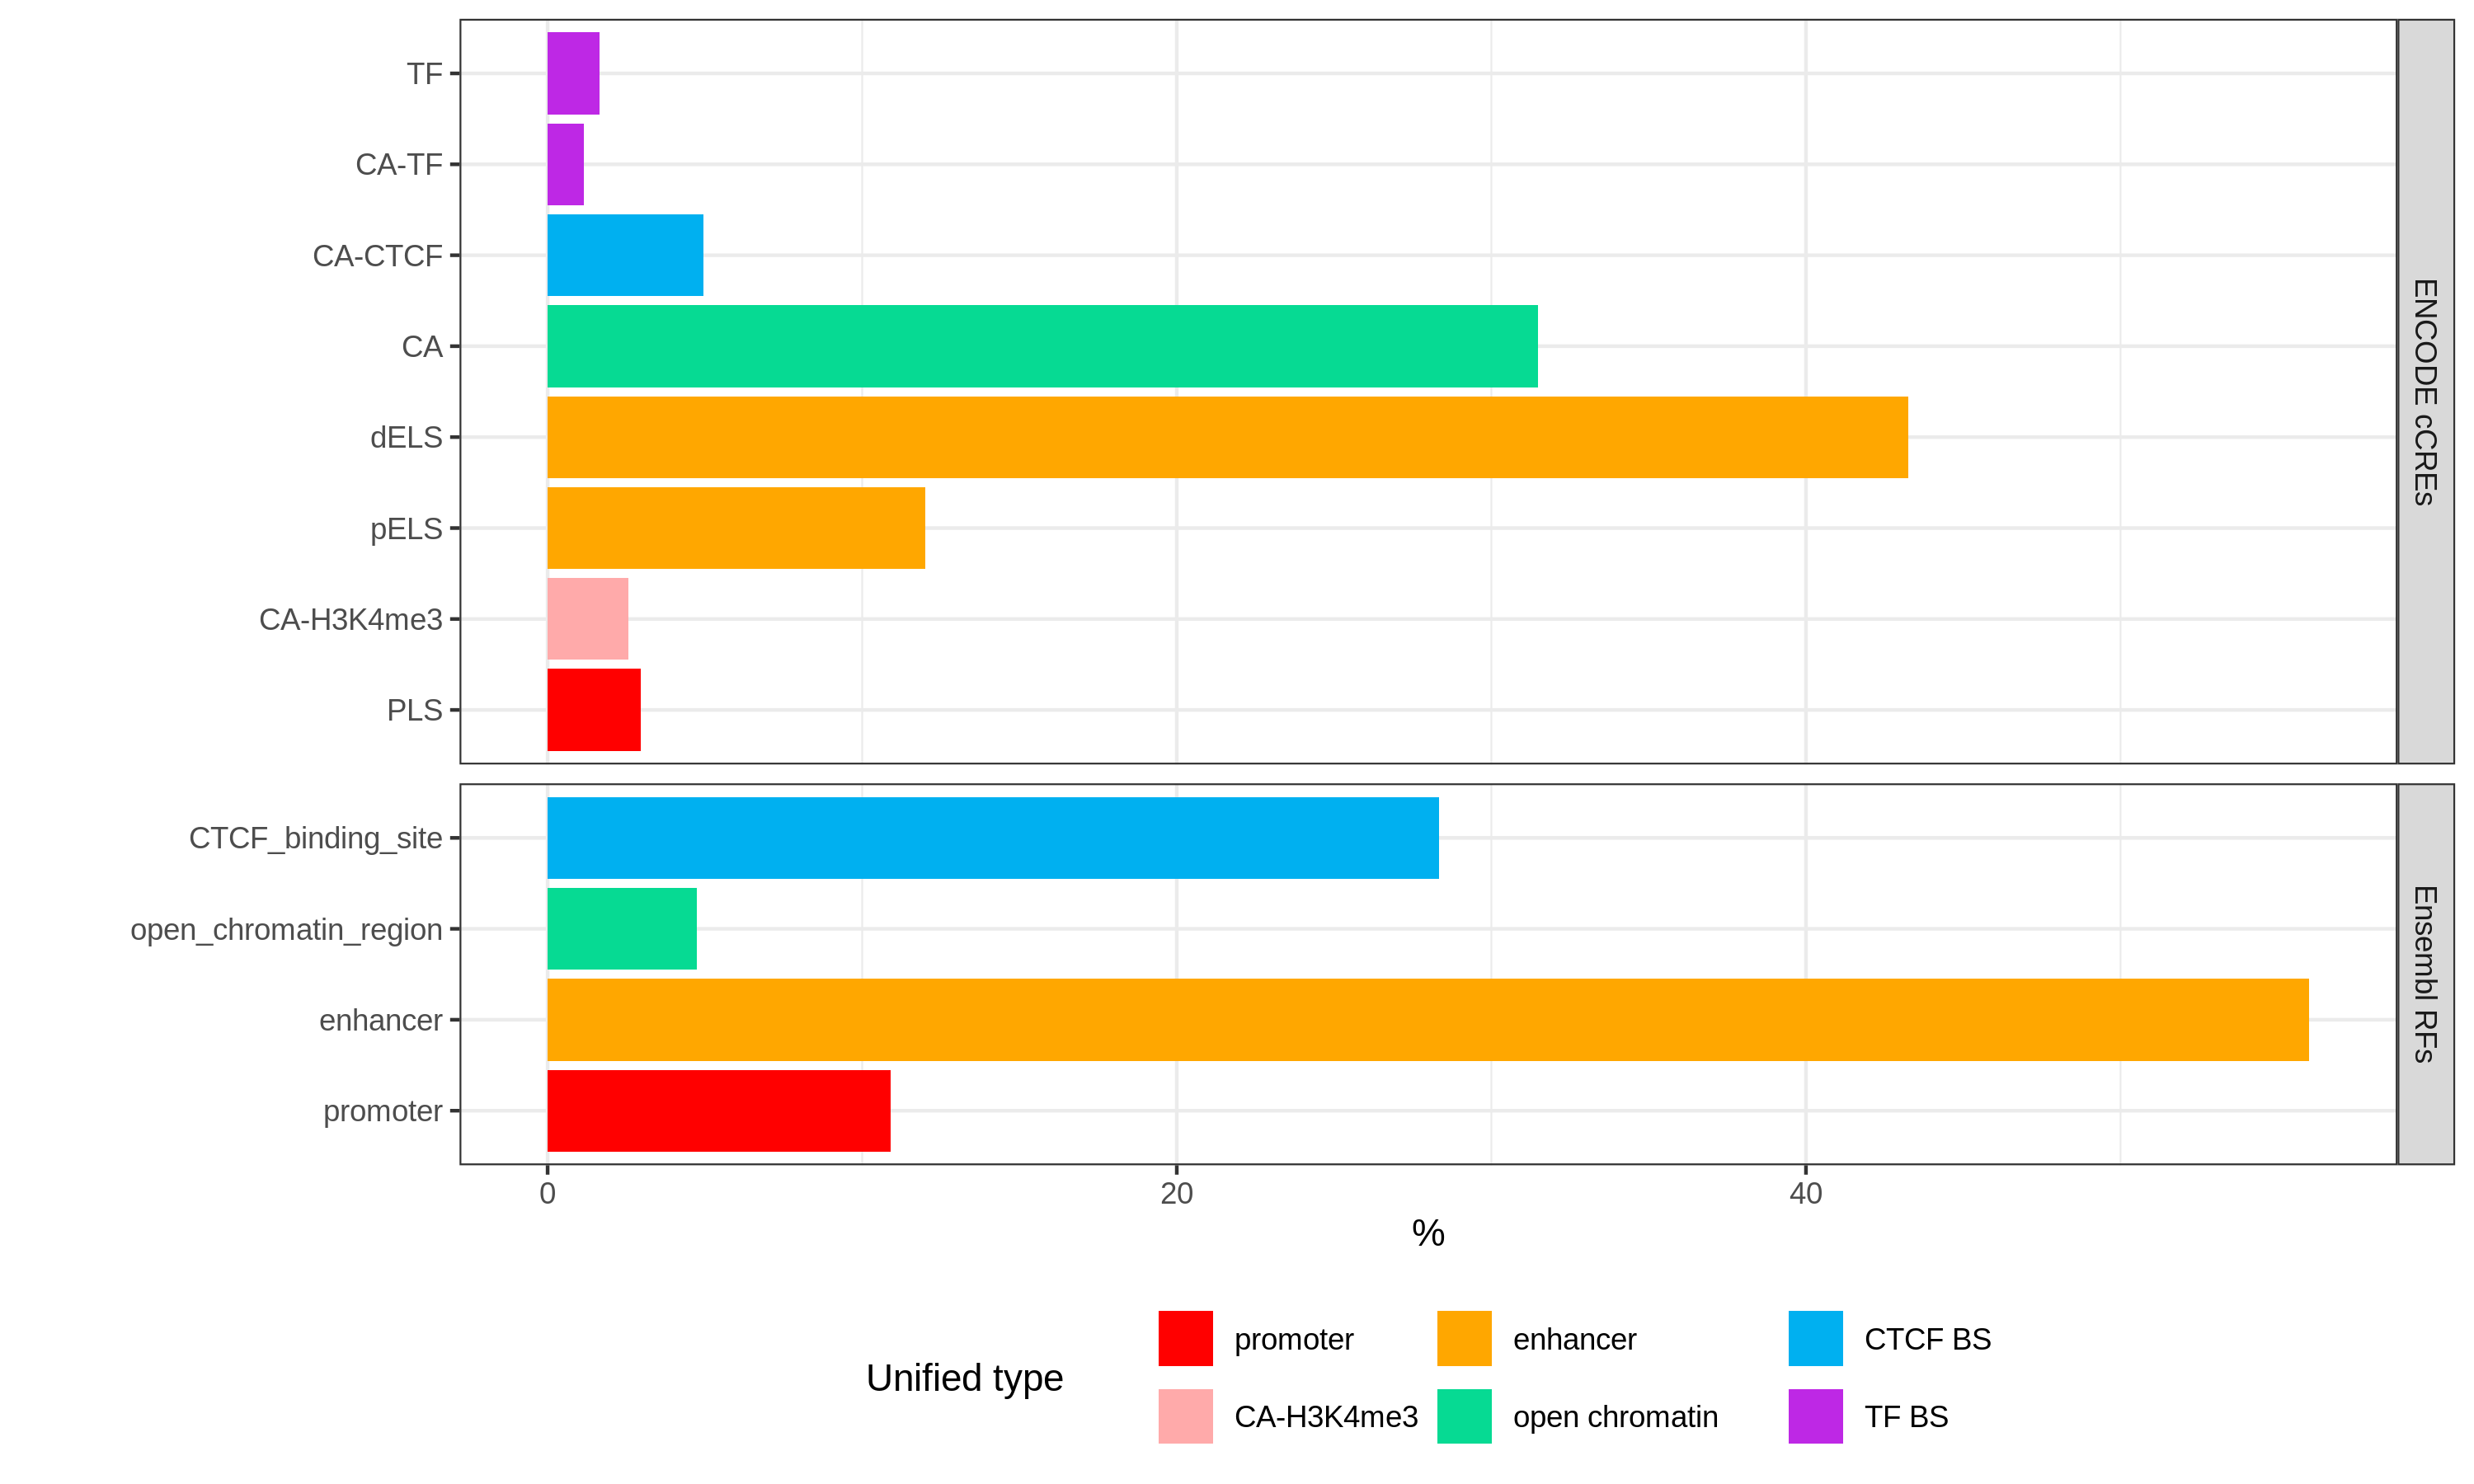

In [34]:
options(
  repr.plot.width = 10,
  repr.plot.height = 6,
  repr.plot.res = 300
)

ENCODE_cCREs %>%
  as.data.frame() %>%
  group_by(type) %>%
  summarise(r =n() / length(ENCODE_cCREs)) %>%
  mutate(source = 'ENCODE cCREs',
         unified_type = unified_cre_type[type]) %>%
  bind_rows(EnsRegRFs %>%
              as.data.frame() %>%
              group_by(type) %>%
              summarise(r =n() / length(EnsRegRFs)) %>%
              mutate(source = 'Ensembl RFs',
                     unified_type = unified_cre_type[type])) %>%
  mutate(type = factor(type,
                               levels = c('promoter', 'PLS', 'CA-H3K4me3',
                                          'pELS', 'dELS', 'enhancer', 'CA',
                                          'open chromatin', 'open_chromatin_region',
                                          'CTCF_binding_site',
                                          'CA-CTCF', 'CA-TF', 'TF'))) %>%
  mutate(unified_type = factor(unified_type,
                               levels = c('promoter', 'CA-H3K4me3',
                                          'enhancer', 'open chromatin',
                                          'CTCF BS', 'TF BS'))) %>%
  ggplot() +
  geom_col(aes(x = type, y = r*100,
               fill = unified_type), width = 0.9) +
  coord_flip() +
  facet_grid(rows = vars(source), drop = TRUE,
             scales = 'free_y', space = 'free_y') +
  theme_bw()+
  scale_fill_manual(values = cCREs_colors) +
  theme(legend.position = 'bottom') +
  labs(y = '%', x = '', fill = 'Unified type')


In [35]:
# user defined region
query_regions


GRanges object with 2 ranges and 1 metadata column:
      seqnames          ranges strand |                   name
         <Rle>       <IRanges>  <Rle> |            <character>
  [1]        6 6857726-6873388      * | query_region_1_6_685..
  [2]        6 6877441-6887003      * | query_region_2_6_687..
  -------
  seqinfo: 1 sequence from an unspecified genome; no seqlengths

### Identify features in the query regions

In [42]:
query_ENCODE_cCREs_hits <- findOverlaps(query_regions, ENCODE_cCREs,
                                        ignore.strand = TRUE)

query_EnsReg_RFs_hits <- findOverlaps(query_regions, EnsRegRFs,
                                        ignore.strand = TRUE)


ENCODE_cCREs_region_1 <- ENCODE_cCREs[subjectHits(query_ENCODE_cCREs_hits)[queryHits(query_ENCODE_cCREs_hits) == 1]]
ENCODE_cCREs_region_2 <- ENCODE_cCREs[subjectHits(query_ENCODE_cCREs_hits)[queryHits(query_ENCODE_cCREs_hits) == 2]]
ENCODE_cCREs_region_1 %>%
  as.data.frame() %>%
  mutate(region = mcols(query_regions)[,'name'][1]) %>%
  bind_rows(ENCODE_cCREs_region_2 %>%
              as.data.frame() %>%
              mutate(region = mcols(query_regions)[,'name'][2])) %>%
  mutate( unified_type = unified_cre_type[type]) -> ENCODE_cCREs_in_query



In [44]:
print(paste('ENCODE cCREs in region', mcols(query_regions)[2, 'name'], ":", length(ENCODE_cCREs_region_1), sep = " "))

[1] "ENCODE cCREs in region query_region_2_6_6877441_6887003 : 35"


In [45]:
print(paste('ENCODE cCREs in region', mcols(query_regions)[2, 'name'], ":", length(ENCODE_cCREs_region_2), sep = " "))

[1] "ENCODE cCREs in region query_region_2_6_6877441_6887003 : 16"


In [43]:
EnsReg_RFs_region_1 <- EnsRegRFs[subjectHits(query_EnsReg_RFs_hits)[queryHits(query_EnsReg_RFs_hits) == 1]]
EnsReg_RFs_region_2 <- EnsRegRFs[subjectHits(query_EnsReg_RFs_hits)[queryHits(query_EnsReg_RFs_hits) == 2]]
EnsReg_RFs_region_1 %>%
  as.data.frame() %>%
  mutate(region = mcols(query_regions)[,'name'][1]) %>%
  bind_rows(EnsReg_RFs_region_2 %>%
              as.data.frame() %>%
              mutate(region = mcols(query_regions)[,'name'][2])) %>%
  mutate( unified_type = unified_cre_type[type]) -> EnsReg_in_query


In [40]:
print(paste('Ensembl Regulatory Features in region', mcols(query_regions)[1, 'name'], ":", length(EnsReg_RFs_region_1), sep = " "))

[1] "Ensembl Regulatory Features in region query_region_1_6_6857726_6873388 : 8"


In [41]:
print(paste('Ensembl Regulatory Features in region', mcols(query_regions)[2, 'name'], ":", length(EnsReg_RFs_region_2), sep = " "))

[1] "Ensembl Regulatory Features in region query_region_2_6_6877441_6887003 : 3"


#### Combine the features information in a single table

In [46]:
ENCODE_cCREs_in_query %>%
  select(seqnames, start, end, name, type, unified_type, region) %>%
  mutate(source = 'ENCODE') %>%
  bind_rows(EnsReg_in_query %>%
              select(seqnames, start, end, ID, type, unified_type, region) %>%
              dplyr::rename(name = ID) %>%
              mutate(source = 'Ensembl')) -> CREs_in_query


### Number of features in the query regions

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by source, region, unified_type, and type.
ℹ Output is grouped by source, region, and unified_type.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(source, region, unified_type, type))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.


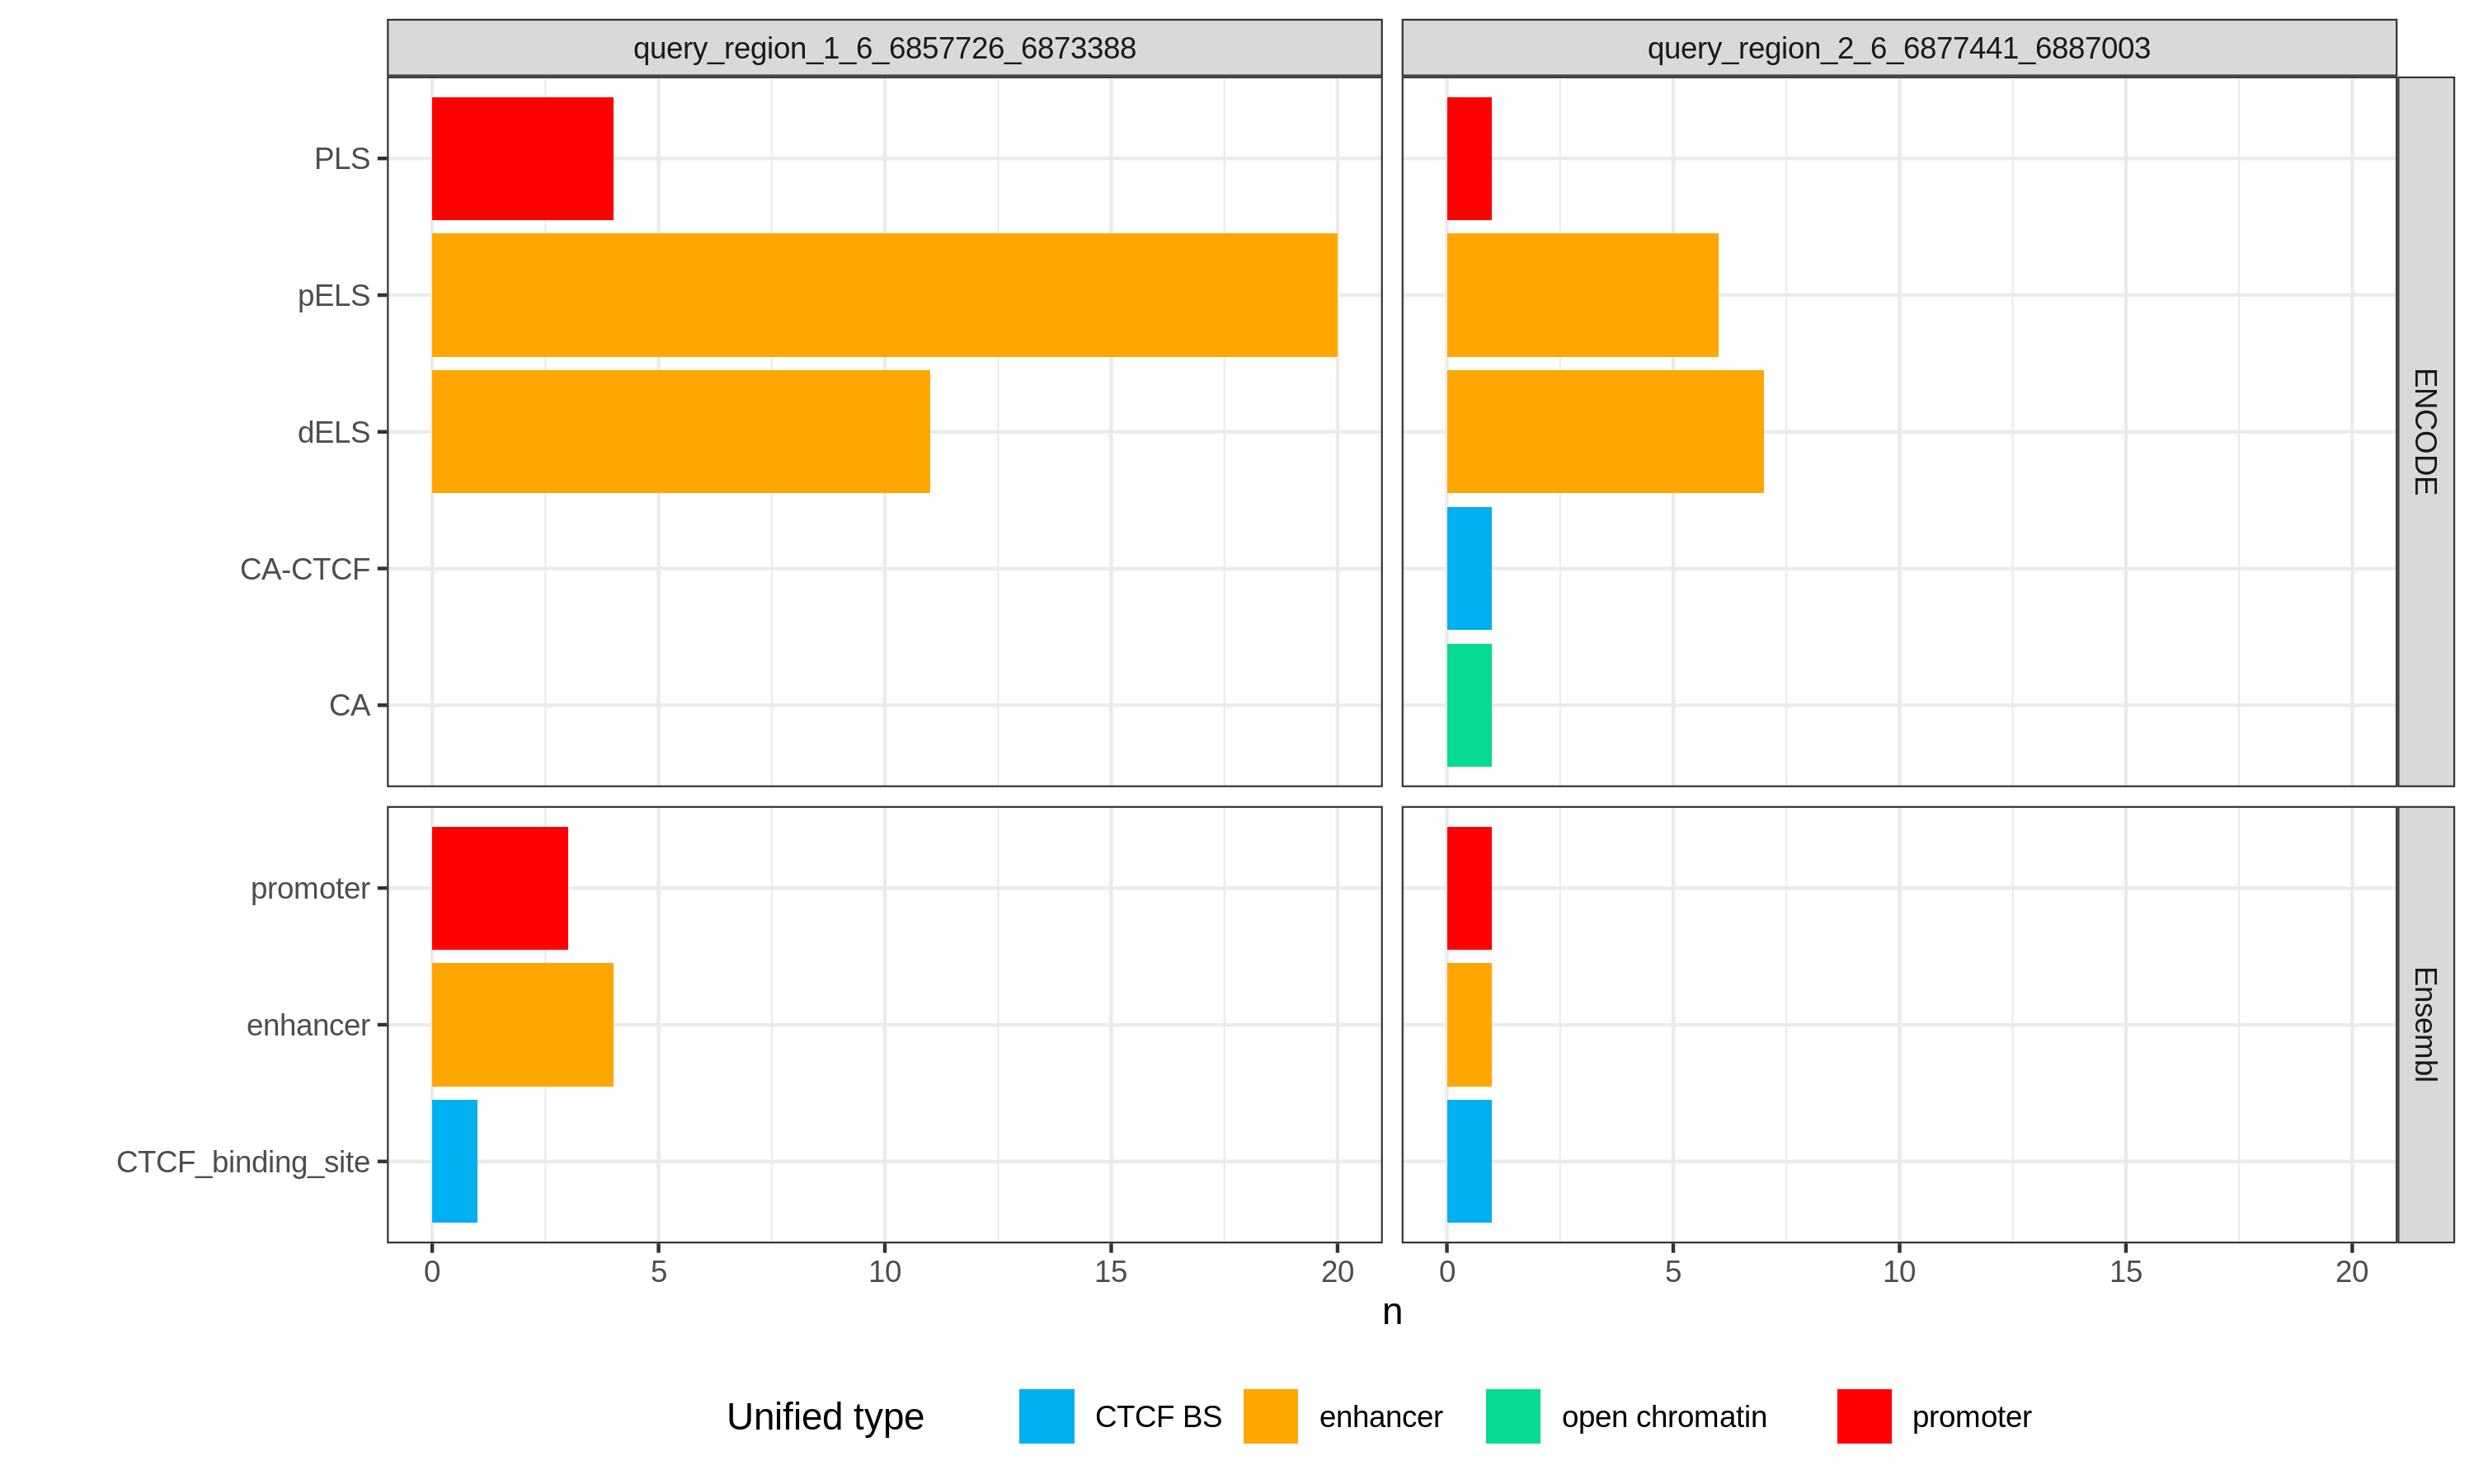

In [47]:
options(
  repr.plot.width = 10,
  repr.plot.height = 6,
  repr.plot.res = 300
)

# Number of features per resource and region
CREs_in_query %>%
  group_by(source, region, unified_type, type) %>%
  summarise(n = n()) %>%
  ggplot() +
  geom_col(aes(x = type, y = n, fill = unified_type), width = 0.9) +
  coord_flip() +
  facet_grid(cols = vars(region), rows = vars(source), drop = TRUE,
             scales = 'free_y', space = 'free_y') +
  theme_bw()+
  scale_fill_manual(values = cCREs_colors) +
  theme(legend.position = 'bottom') +
  labs(y = 'n', x = '', fill = 'Unified type')

### Selecting promoters in the query region

In [48]:
selected_feature_types <- c("promoter", "PLS")


CREs_in_query %>%
  filter(type %in% selected_feature_types) -> promoters_in_query

head(promoters_in_query)



,seqnames,start,end,name,type,unified_type,region,source
,<fct>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,6,6863212,6863416,EM10E1613122,PLS,promoter,query_region_1_6_6857726_6873388,ENCODE
2,6,6864907,6865211,EM10E1161065,PLS,promoter,query_region_1_6_6857726_6873388,ENCODE
3,6,6865265,6865420,EM10E1161066,PLS,promoter,query_region_1_6_6857726_6873388,ENCODE
4,6,6871471,6871715,EM10E0813276,PLS,promoter,query_region_1_6_6857726_6873388,ENCODE
5,6,6881861,6882203,EM10E1161083,PLS,promoter,query_region_2_6_6877441_6887003,ENCODE
6,6,6862844,6863344,ENSMUSR6_94PJS,promoter,promoter,query_region_1_6_6857726_6873388,Ensembl


### Identifying active promoters in Forebrain E13.5

In [49]:
# Identify promoters that are active in Forebrain E13.5 by overlapping them with open
# chromatin peaks

ENCODE_promoters_in_query_oc_hits <- findOverlaps(
  makeGRangesFromDataFrame(promoters_in_query %>%
                             filter(source == 'ENCODE'), keep.extra.columns = TRUE),
  ensembl_atac, ignore.strand = TRUE)

EnsReg_promoters_in_query_oc_hits <- findOverlaps(
  makeGRangesFromDataFrame(promoters_in_query %>%
                             filter(source == 'Ensembl'), keep.extra.columns = TRUE),
  ensembl_atac, ignore.strand = TRUE)
promoters_in_query %>%
  filter(source == "ENCODE") %>%
  dplyr::slice(queryHits(ENCODE_promoters_in_query_oc_hits)) %>%
  pull(name) -> active_ENCODE_promoters

promoters_in_query %>%
  filter(source == "Ensembl") %>%
  dplyr::slice(queryHits(EnsReg_promoters_in_query_oc_hits)) %>%
  pull(name) -> active_Ensembl_promoters

promoters_in_query %>%
  filter(name %in% c(active_ENCODE_promoters,
                     active_Ensembl_promoters )) -> active_promoters_in_query

In [50]:
active_promoters_in_query

seqnames,start,end,name,type,unified_type,region,source
<fct>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
6,6863212,6863416,EM10E1613122,PLS,promoter,query_region_1_6_6857726_6873388,ENCODE
6,6871471,6871715,EM10E0813276,PLS,promoter,query_region_1_6_6857726_6873388,ENCODE
6,6881861,6882203,EM10E1161083,PLS,promoter,query_region_2_6_6877441_6887003,ENCODE
6,6862844,6863344,ENSMUSR6_94PJS,promoter,promoter,query_region_1_6_6857726_6873388,Ensembl
6,6869523,6870030,ENSMUSR6_94PLR,promoter,promoter,query_region_1_6_6857726_6873388,Ensembl
6,6871617,6872117,ENSMUSR6_94PMD,promoter,promoter,query_region_1_6_6857726_6873388,Ensembl
6,6882058,6882575,ENSMUSR6_B3CTP,promoter,promoter,query_region_2_6_6877441_6887003,Ensembl


### Save output files

In [ ]:

rtracklayer::export(
  GRanges(active_promoters_in_query),
  file.path(paths$output_dir, "GRCm39_forebrain_E13.5_active_promoters_R.bed"),
  format = "BED"
)
save.image(file = file.path(paths$output_dir, "session4_GRCm39.RData"),
           compress = 'xz')
